In [2]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
import numpy as np

dataset = fetch_openml(data_id=4534, as_frame=False, parser='auto')
X = dataset.data
y_raw = dataset.target

le = LabelEncoder()
y_int = le.fit_transform(y_raw)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_int, test_size=0.4, stratify=y_int, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_val_std = scaler.transform(X_val)
X_test_std = scaler.transform(X_test)

enc = OneHotEncoder(sparse_output=False, categories='auto')

Y_train_oh = enc.fit_transform(y_train.reshape(-1, 1))
Y_val_oh = enc.transform(y_val.reshape(-1, 1))
Y_test_oh = enc.transform(y_test.reshape(-1, 1))

print("Shapes Verification:")
print("\nTraining Set:")
print(f"Features shape: {X_train_std.shape}")
print(f"One-Hot labels shape: {Y_train_oh.shape}")
print(f"Original labels shape: {y_train.shape}")

print("\nValidation Set:")
print(f"Features shape: {X_val_std.shape}")
print(f"One-Hot labels shape: {Y_val_oh.shape}")
print(f"Original labels shape: {y_val.shape}")

print("\nTest Set:")
print(f"Features shape: {X_test_std.shape}")
print(f"One-Hot labels shape: {Y_test_oh.shape}")
print(f"Original labels shape: {y_test.shape}")

Shapes Verification:

Training Set:
Features shape: (6633, 30)
One-Hot labels shape: (6633, 2)
Original labels shape: (6633,)

Validation Set:
Features shape: (2211, 30)
One-Hot labels shape: (2211, 2)
Original labels shape: (2211,)

Test Set:
Features shape: (2211, 30)
One-Hot labels shape: (2211, 2)
Original labels shape: (2211,)


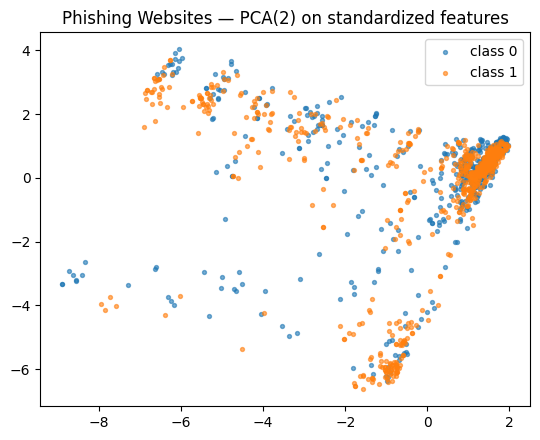

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

assert X_train_std.ndim == 2 and X_val_std.ndim == 2 and X_test_std.ndim == 2, "Standardized feature arrays must be 2D"
assert Y_train_oh.shape[1] == 2 and Y_val_oh.shape[1] == 2 and Y_test_oh.shape[1] == 2, "One-hot should have 2 columns"
assert np.allclose(Y_train_oh.sum(axis=1), 1), "One-hot rows must sum to 1"

n_show = min(1500, X_train_std.shape[0])
idx = np.random.choice(X_train_std.shape[0], size=n_show, replace=False)
X_show = X_train_std[idx]; y_show = y_train[idx]
Z = PCA(n_components=2, random_state=0).fit_transform(X_show)

plt.figure(figsize=(5.5,4.5))
plt.scatter(Z[y_show==0,0], Z[y_show==0,1], s=8, alpha=0.6, label="class 0")
plt.scatter(Z[y_show==1,0], Z[y_show==1,1], s=8, alpha=0.6, label="class 1")
plt.title("Phishing Websites — PCA(2) on standardized features")
plt.legend(); plt.tight_layout(); plt.show()

In [4]:
def softmax_logits(logits: np.ndarray, axis=1):
    z = logits - logits.max(axis=axis, keepdims=True)
    exp = np.exp(z)
    return exp / exp.sum(axis=axis, keepdims=True)

def cross_entropy(probs: np.ndarray, Y_onehot: np.ndarray, eps=1e-12):
    p = np.clip(probs, eps, 1 - eps)
    ce = -np.sum(Y_onehot * np.log(p), axis=1)
    return ce.mean()

def iterate_minibatches(X, Y, batch_size=128, shuffle=True):
    n = X.shape[0]; idx = np.arange(n)
    if shuffle: np.random.shuffle(idx)
    for i in range(0, n, batch_size):
        j = idx[i:i+batch_size]
        yield X[j], Y[j]

### Forward Pass and Backpropagation

In [5]:
class MLP_Numpy:
    """3-layer MLP: D -> H1 -> H2 -> C, ReLU hidden, softmax-CE output.
    Implement forward() and loss_and_grads() WITHOUT autograd."""
    
    def __init__(self, D_in, H1, H2, C,weight_scale=None, seed=42,l2=1e-4, momentum=0.9, lr=1e-2):
        rng = np.random.default_rng(seed)

        def he(fan_in, fan_out):
            std = np.sqrt(2.0 / fan_in) if weight_scale is None else weight_scale
            return rng.normal(0.0, std, size=(fan_in, fan_out))

        self.W1 = he(D_in, H1)
        self.b1 = np.zeros(H1)

        self.W2 = he(H1, H2)
        self.b2 = np.zeros(H2)

        self.W3 = he(H2, C )
        self.b3 = np.zeros(C)

        self.v = {
            name: np.zeros_like(param)
            for name, param in dict(
                W1=self.W1, 
                b1=self.b1,
                W2=self.W2, 
                b2=self.b2,
                W3=self.W3, 
                b3=self.b3
            ).items()
        }
        
        self.l2 = l2
        self.momentum = momentum
        self.lr = lr

    @staticmethod
    def relu(x):
        return np.maximum(0.0, x)

    @staticmethod
    def relu_grad(x):
        """Derivative of ReLU with respect to its input."""
        
        grad = np.zeros_like(x)
        grad[x > 0] = 1.0
        return grad

    def forward(self, X):
        """Forward pass for the MLP."""


        Z1 = X @ self.W1 + self.b1
        A1 = self.relu(Z1)

        # Layer 2
        Z2 = A1 @ self.W2 + self.b2
        A2 = self.relu(Z2)

        # Layer 3 (Logits)
        Z3 = A2 @ self.W3 + self.b3
        
        # Output (Softmax)
        P = softmax_logits(Z3)

        cache = (X, Z1, A1, Z2, A2, Z3)
        return P, cache

    def loss_and_grads(self, X, Y_onehot):
        """Compute softmax cross-entropy loss and gradients for all parameters."""

        N = X.shape[0]
        
        # Forward pass
        P, cache = self.forward(X)
        X_in, Z1, A1, Z2, A2, Z3 = cache

        # Loss Computation
        data_loss = cross_entropy(P, Y_onehot)
        
        # L2 Regularization loss
        l2_loss = 0.5 * self.l2 * (np.sum(self.W1**2) + np.sum(self.W2**2) + np.sum(self.W3**2))
        
        loss = data_loss + l2_loss

        # Backward pass
        grads = {}

        # Gradient of Loss 
        dZ3 = (P - Y_onehot) / N

        # Gradients for W3, b3
        grads['W3'] = A2.T @ dZ3 + (self.l2 * self.W3)
        grads['b3'] = np.sum(dZ3, axis=0)

        # Gradient wrt A2
        dA2 = dZ3 @ self.W3.T
        
        # Gradient wrt Z2 
        dZ2 = dA2 * self.relu_grad(Z2)

        # Gradients for W2, b2
        grads['W2'] = A1.T @ dZ2 + (self.l2 * self.W2)
        grads['b2'] = np.sum(dZ2, axis=0)

        # Gradient wrt A1
        dA1 = dZ2 @ self.W2.T

        # Gradient wr
        dZ1 = dA1 * self.relu_grad(Z1)

        # Gradients for W1, b1
        grads['W1'] = X_in.T @ dZ1 + (self.l2 * self.W1)
        grads['b1'] = np.sum(dZ1, axis=0)

        return loss, grads

    def step(self, grads):
        """Momentum SGD update of all parameters in-place."""
        
        for name in ["W1", "b1", "W2", "b2", "W3", "b3"]:
            self.v[name] = self.momentum * self.v[name] - self.lr * grads[name]
            setattr(self, name, getattr(self, name) + self.v[name])


In [6]:
D = 10; H1 = 6; H2 = 4; C = 2; n = 5
model = MLP_Numpy(D, H1, H2, C)
X = np.random.randn(n, D)
Y = np.eye(C)[np.random.randint(0, C, size=n)]

try:
    P, cache = model.forward(X)
    assert P.shape == (n, C), f"softmax probs must be (n, C), got {P.shape}"
    loss, grads = model.loss_and_grads(X, Y)
    for k in ["W1", "b1", "W2", "b2", "W3", "b3"]:
        assert grads[k].shape == getattr(model, k).shape, f"grad shape mismatch for {k}"
    print("✓ Forward/backward basic shape checks passed.")
except NotImplementedError:
    print("Implement MLP methods first to run this check.")
id

✓ Forward/backward basic shape checks passed.


<function id(obj, /)>

### Finite-difference Gradient Check

In [8]:
def numerical_grad_check(model, X_small, Y_small, eps=1e-5, atol=1e-4, rtol=1e-2):
    """Finite-difference gradient check for MLP_Numpy.

    For each parameter tensor in the model, this function compares the
    analytical gradient from `loss_and_grads` with a numerical gradient
    computed via centered finite differences.
    """

    _, analytical_grads = model.loss_and_grads(X_small, Y_small)
    
    all_ok = True
    
    for name in ["W1", "b1", "W2", "b2", "W3", "b3"]:
        param = getattr(model, name)      
        grad_analytic = analytical_grads[name] 
        
        it = np.nditer(param, flags=['multi_index'], op_flags=['readwrite'])
        
        while not it.finished:
            idx = it.multi_index
            original_val = param[idx]
                        
            # Perturb positive 
            param[idx] = original_val + eps
            loss_plus, _ = model.loss_and_grads(X_small, Y_small)
            
            # Perturb negative
            param[idx] = original_val - eps
            loss_minus, _ = model.loss_and_grads(X_small, Y_small)
            
            # Restore original value 
            param[idx] = original_val
            
            # Calculate numerical gradient
            grad_numeric = (loss_plus - loss_minus) / (2 * eps)
                    
            # Check relative and absolute error
            diff = np.abs(grad_numeric - grad_analytic[idx])
            denom = np.maximum(np.abs(grad_numeric), np.abs(grad_analytic[idx])) + 1e-15
            rel_error = diff / denom
            
            if diff > atol and rel_error > rtol:
                all_ok = False
                print(f"Mismatch in {name}{idx}: "
                      f"Numeric {grad_numeric:.8f} vs Analytic {grad_analytic[idx]:.8f} "
                      f"| Diff: {diff:.2e}")
            
            it.iternext()
            
    if all_ok:
        print("Numerical gradient check passed!")
    else:
        print("Numerical gradient check failed.")
        
    return all_ok


In [9]:
D, H1, H2, C, n = 10, 6, 4, 2, 5
np.random.seed(0)

model = MLP_Numpy(D, H1, H2, C)

# Random inputs and one-hot labels
X_small = np.random.randn(n, D)
y_small_int = np.random.randint(0, C, size=n)
Y_small = np.eye(C)[y_small_int]

try:
    # Forward sanity checks 
    P, _ = model.forward(X_small)
    assert P.shape == (n, C), f"Expected probs shape {(n, C)}, got {P.shape}"
    row_sums = P.sum(axis=1)
    assert np.allclose(row_sums, 1.0, atol=1e-5), \
        f"Softmax rows must sum to 1 (got {row_sums})"
    print("✓ Forward pass shape + softmax checks passed.")

    # Numerical gradient check
    ok = numerical_grad_check(model, X_small, Y_small)
    if ok:
        print("✓ Numerical gradient check PASSED for this random batch.")
    else:
        print("✗ Numerical gradient check FAILED — see mismatch printed above.")
except NotImplementedError as e:
    print("NotImplementedError raised:", e)
    print("Make sure you have implemented:")
    print("  - MLP_Numpy.forward (A2)")
    print("  - MLP_Numpy.loss_and_grads (A2)")
    print("  - numerical_grad_check (A3)")


✓ Forward pass shape + softmax checks passed.
Numerical gradient check passed!
✓ Numerical gradient check PASSED for this random batch.


### Training Loop with SGD + Momentum and Early Stopping

In [10]:
def train_mlp(model, Xtr, Ytr, Xva, Yva, epochs=80, batch=128, patience=8):
    """Train MLP_Numpy with mini-batch SGD + momentum and early stopping."""

    hist = {"train_loss": [], "val_loss": [], "train_acc": [],  "val_acc": []}
    
    best_val_loss = float('inf')
    patience_counter = 0
    
    for epoch in range(epochs):
        epoch_loss = 0.0
        correct = 0
        total = 0
        num_batches = 0
        
        for X_batch, Y_batch in iterate_minibatches(Xtr, Ytr, batch_size=batch, shuffle=True):
            loss, grads = model.loss_and_grads(X_batch, Y_batch)
            model.step(grads)
            epoch_loss += loss
            P_batch, _ = model.forward(X_batch)
            preds = np.argmax(P_batch, axis=1)
            truth = np.argmax(Y_batch, axis=1)
            correct += np.sum(preds == truth)
            total += X_batch.shape[0]
            num_batches += 1
            
        avg_train_loss = epoch_loss / num_batches
        train_acc = correct / total
        
        P_val, _ = model.forward(Xva)
        val_loss = cross_entropy(P_val, Yva)
        
        val_preds = np.argmax(P_val, axis=1)
        val_truth = np.argmax(Yva, axis=1)
        val_acc = np.mean(val_preds == val_truth)
        
        hist["train_loss"].append(avg_train_loss)
        hist["val_loss"].append(val_loss)
        hist["train_acc"].append(train_acc)
        hist["val_acc"].append(val_acc)
        
        if epoch == 0 or (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1}/{epochs} | "
                  f"Train Loss: {avg_train_loss:.4f} Acc: {train_acc:.4f} | "
                  f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")
            
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch+1} (no improvement for {patience} epochs)")
                break
                
    return hist

def predict_classes(model, X):
    """Return integer class predictions via softmax."""

    P, _ = model.forward(X)
    return np.argmax(P, axis=1)

In [12]:
try:
    n_small = min(256, X_train_std.shape[0])
    idx = np.random.choice(X_train_std.shape[0], size=n_small, replace=False)
    Xtr_s, Ytr_s = X_train_std[idx], Y_train_oh[idx]
    Xva_s, Yva_s = X_val_std, Y_val_oh

    model = MLP_Numpy(D_in=Xtr_s.shape[1], H1=64, H2=32, C=Ytr_s.shape[1], l2=5e-4, lr=5e-3, momentum=0.9)
    hist = train_mlp(model, Xtr_s, Ytr_s, Xva_s, Yva_s, epochs=10, batch=64, patience=3)
    assert len(hist.get("val_loss",[]))>0, "val_loss history must be recorded"
    assert min(hist["val_loss"]) <= hist["val_loss"][0], "validation loss should not strictly worsen"
    print("✓ Training sanity check: curves recorded and show some improvement.")
except NotImplementedError:
    print("Implement training loop first to run this check.")

Epoch 1/10 | Train Loss: 1.0165 Acc: 0.4297 | Val Loss: 0.8726 Acc: 0.4224
Epoch 5/10 | Train Loss: 0.5578 Acc: 0.8164 | Val Loss: 0.4962 Acc: 0.7956
Epoch 10/10 | Train Loss: 0.3685 Acc: 0.8828 | Val Loss: 0.3666 Acc: 0.8562
✓ Training sanity check: curves recorded and show some improvement.


### Final Training, Curves and Evaluations with Hyperparamter Tuning

In [13]:
def plot_curves(hist, title="MLP loss curves"):
    plt.figure(); plt.plot(hist.get("train_loss",[]), label="train"); plt.plot(hist.get("val_loss",[]), label="val")
    plt.xlabel("epoch"); plt.ylabel("loss"); plt.legend(); plt.title(title); plt.show()


In [14]:
import itertools

A_HPARAMS = {
    "H1": 128,
    "H2": 64,
    "lr": 5e-3,
    "l2": 5e-4,
    "momentum": 0.9,
    "batch": 128,
    "epochs": 50,
    "patience": 8,
}
print("Base A_HPARAMS:", A_HPARAMS)

A_GRID = {
    "H1": [64, 128],
    "H2": [32, 64],
    "lr": [5e-3, 1e-2],
    "l2": [1e-4, 5e-4],
}

best_cfg = None
best_val_loss = float("inf")
best_model = None
best_hist = None

keys = A_GRID.keys()
values = A_GRID.values()

for combination in itertools.product(*values):
    current_grid_params = dict(zip(keys, combination))
    
    # Merge with base A_HPARAMS
    current_cfg = A_HPARAMS.copy()
    current_cfg.update(current_grid_params)
    
    print(f"Training with: {current_grid_params}")
    
    model = MLP_Numpy(
        D_in=X_train_std.shape[1],
        H1=current_cfg["H1"],
        H2=current_cfg["H2"],
        C=Y_train_oh.shape[1],
        l2=current_cfg["l2"],
        lr=current_cfg["lr"],
        momentum=current_cfg["momentum"]
    )
    
    hist = train_mlp(
        model, 
        X_train_std, Y_train_oh, 
        X_val_std, Y_val_oh, 
        epochs=current_cfg["epochs"], 
        batch=current_cfg["batch"], 
        patience=current_cfg["patience"]
    )
    
    min_val_curr = min(hist["val_loss"])
    
    if min_val_curr < best_val_loss:
        best_val_loss = min_val_curr
        best_cfg = current_cfg
        best_model = model
        best_hist = hist

print("-" * 40)
print("Best A HParams:", best_cfg)
print("Best val_loss=", best_val_loss)

Base A_HPARAMS: {'H1': 128, 'H2': 64, 'lr': 0.005, 'l2': 0.0005, 'momentum': 0.9, 'batch': 128, 'epochs': 50, 'patience': 8}
Training with: {'H1': 64, 'H2': 32, 'lr': 0.005, 'l2': 0.0001}
Epoch 1/50 | Train Loss: 0.5170 Acc: 0.7616 | Val Loss: 0.3070 Acc: 0.8838
Epoch 5/50 | Train Loss: 0.1963 Acc: 0.9284 | Val Loss: 0.1943 Acc: 0.9245
Epoch 10/50 | Train Loss: 0.1630 Acc: 0.9400 | Val Loss: 0.1691 Acc: 0.9317
Epoch 15/50 | Train Loss: 0.1461 Acc: 0.9451 | Val Loss: 0.1568 Acc: 0.9385
Epoch 20/50 | Train Loss: 0.1340 Acc: 0.9484 | Val Loss: 0.1508 Acc: 0.9435
Epoch 25/50 | Train Loss: 0.1246 Acc: 0.9531 | Val Loss: 0.1440 Acc: 0.9484
Epoch 30/50 | Train Loss: 0.1171 Acc: 0.9575 | Val Loss: 0.1422 Acc: 0.9484
Epoch 35/50 | Train Loss: 0.1108 Acc: 0.9597 | Val Loss: 0.1351 Acc: 0.9489
Epoch 40/50 | Train Loss: 0.1048 Acc: 0.9614 | Val Loss: 0.1345 Acc: 0.9498
Epoch 45/50 | Train Loss: 0.1002 Acc: 0.9641 | Val Loss: 0.1296 Acc: 0.9521
Epoch 50/50 | Train Loss: 0.0963 Acc: 0.9650 | Val Los

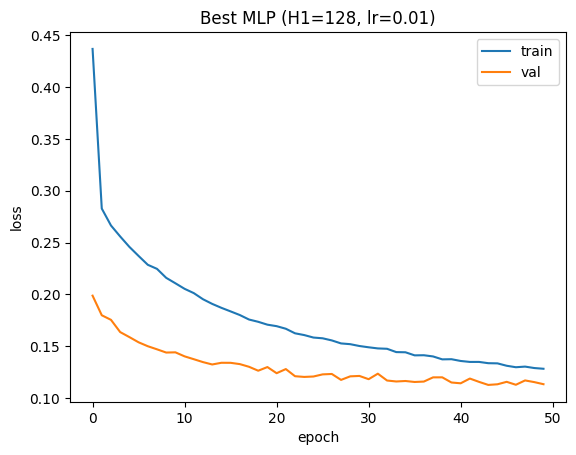

In [15]:
if best_hist is not None:
    plot_curves(best_hist, title=f"Best MLP (H1={best_cfg['H1']}, lr={best_cfg['lr']})")

In [17]:
from sklearn.metrics import classification_report, confusion_matrix

if best_model is not None:
    test_preds = predict_classes(best_model, X_test_std)

    print("\nClassification Report:")
    print(classification_report(y_test, test_preds, digits=4))

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, test_preds))


Classification Report:
              precision    recall  f1-score   support

           0     0.9644    0.9398    0.9519       980
           1     0.9530    0.9724    0.9626      1231

    accuracy                         0.9579      2211
   macro avg     0.9587    0.9561    0.9573      2211
weighted avg     0.9581    0.9579    0.9579      2211

Confusion Matrix:
[[ 921   59]
 [  34 1197]]
